In [2]:
import pandas as pd
import numpy as np

chunks = []
current_movie = None

with open('../data/combined_data_1.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if line.endswith(':'):
            current_movie = int(line[:-1])
        else:
            parts = line.split(',')
            chunks.append([current_movie, int(parts[0]),
                           int(parts[1]), parts[2]])

df = pd.DataFrame(chunks,
    columns=['movie_id','user_id','rating','date'])
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(24053764, 4)
movie_id             int64
user_id              int64
rating               int64
date        datetime64[ns]
dtype: object
movie_id    0
user_id     0
rating      0
date        0
dtype: int64


Average rating: 3.6
Rating counts: rating
1    1118186
2    2439073
3    6904181
4    8085741
5    5506583
Name: count, dtype: int64


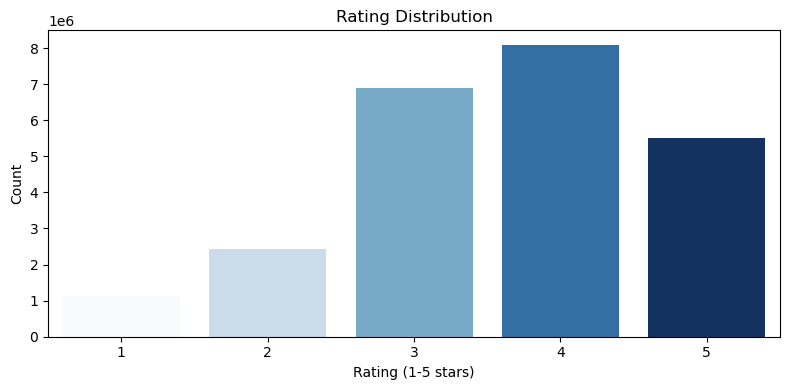

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Average rating:", df['rating'].mean().round(2))
print("Rating counts:", df['rating'].value_counts().sort_index())

plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=df, hue='rating', palette='Blues', legend=False)
plt.title('Rating Distribution')
plt.xlabel('Rating (1-5 stars)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("eda_fig1_rating_dist.png", dpi=150, bbox_inches='tight')
plt.show()

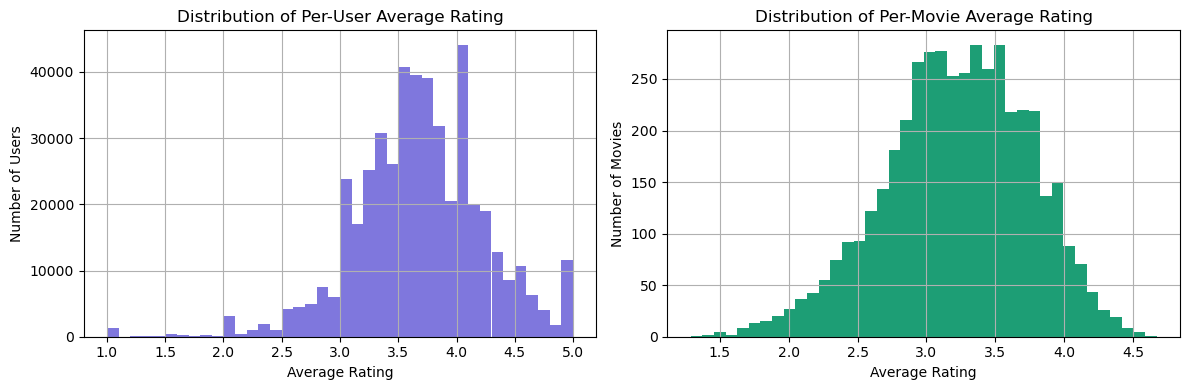

In [3]:
# Distribution of per-user average ratings
user_avg = df.groupby('user_id')['rating'].mean()
movie_avg = df.groupby('movie_id')['rating'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
user_avg.hist(bins=40, ax=ax1, color='#7F77DD')
ax1.set_title('Distribution of Per-User Average Rating')
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Number of Users')

movie_avg.hist(bins=40, ax=ax2, color='#1D9E75')
ax2.set_title('Distribution of Per-Movie Average Rating')
ax2.set_xlabel('Average Rating')
ax2.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

In [4]:
print(f"Users who always rate 5: {(user_avg == 5).sum():,}")
print(f"Users with avg rating > 4: {(user_avg > 4).sum():,} ({(user_avg > 4).mean():.1%})")
print(f"Movies with avg rating > 4: {(movie_avg > 4).sum():,} ({(movie_avg > 4).mean():.1%})")
print(f"Overall positive bias (avg > 3): {(user_avg > 3).mean():.1%} of users")

Users who always rate 5: 10,862
Users with avg rating > 4: 111,634 (23.7%)
Movies with avg rating > 4: 255 (5.7%)
Overall positive bias (avg > 3): 88.9% of users


In [20]:
top_movies = (df.groupby('movie_id')
               .agg(num_ratings=('rating','count'),
                    avg_rating=('rating','mean'))
               .sort_values('num_ratings', ascending=False)
               .head(20)
               .round(2))

print(top_movies)

titles = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Projects\Data science\netflix\netflix-recommender\data\movie_titles.csv',
    encoding='latin-1',
    header=None,
    names=['movie_id','release_year','title'],
    on_bad_lines='skip',
    engine='python')

top_movies = top_movies.reset_index()
top_movies = top_movies.merge(titles, on='movie_id')
print(top_movies[['title', 'release_year', 'num_ratings', 'avg_rating']])

          num_ratings  avg_rating
movie_id                         
1905           193941        4.15
2152           162597        3.43
3860           160454        3.43
4432           156183        3.76
571            154832        3.96
3938           153996        4.14
4306           151292        4.33
2452           149866        4.43
1962           145519        3.75
3962           140979        4.42
1145           140154        3.18
3624           139428        3.95
2372           137170        3.91
3427           136850        3.33
2782           135601        4.29
3106           135431        3.65
1220           134241        4.01
2862           128446        4.31
4123           121769        3.45
1307           121207        3.31
                                                title  release_year  \
0   Pirates of the Caribbean: The Curse of the Bla...        2003.0   
1                                     What Women Want        2000.0   
2                                      

Top 530 movies (11.8%) account for 80% of all ratings


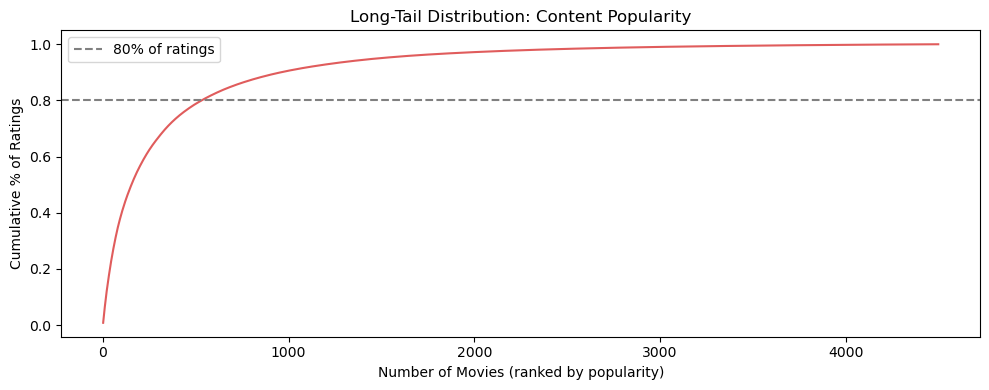

In [6]:
movie_ratings_count = df.groupby('movie_id')['rating'].count().sort_values(ascending=False)

# What % of movies get 80% of ratings?
cumulative_pct = movie_ratings_count.cumsum() / movie_ratings_count.sum()
movies_for_80pct = (cumulative_pct <= 0.80).sum()
print(f"Top {movies_for_80pct} movies ({movies_for_80pct/len(movie_ratings_count):.1%}) account for 80% of all ratings")

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(movie_ratings_count)+1), cumulative_pct.values, color='#E05C5C')
plt.axhline(0.8, linestyle='--', color='gray', label='80% of ratings')
plt.xlabel('Number of Movies (ranked by popularity)')
plt.ylabel('Cumulative % of Ratings')
plt.title('Long-Tail Distribution: Content Popularity')
plt.legend()
plt.tight_layout()
plt.show()

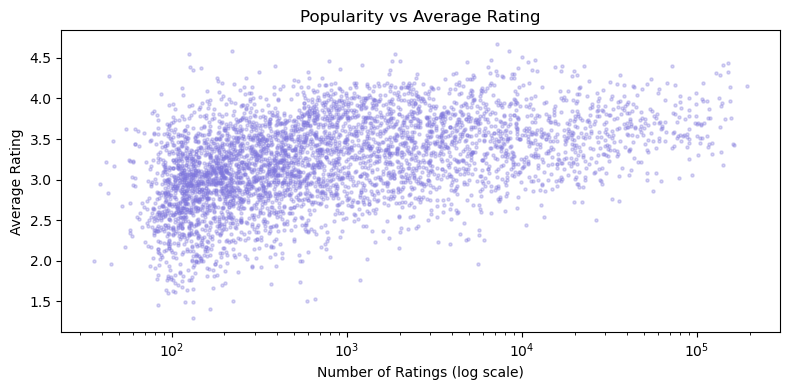

In [7]:
movie_stats = df.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
)

plt.figure(figsize=(8, 4))
plt.scatter(movie_stats['num_ratings'], movie_stats['avg_rating'],
            alpha=0.3, s=5, color='#7F77DD')
plt.xscale('log')
plt.xlabel('Number of Ratings (log scale)')
plt.ylabel('Average Rating')
plt.title('Popularity vs Average Rating')
plt.tight_layout()
plt.show()

Avg ratings per user: 51.1
Max ratings by one user: 4467
Min ratings by one user: 1


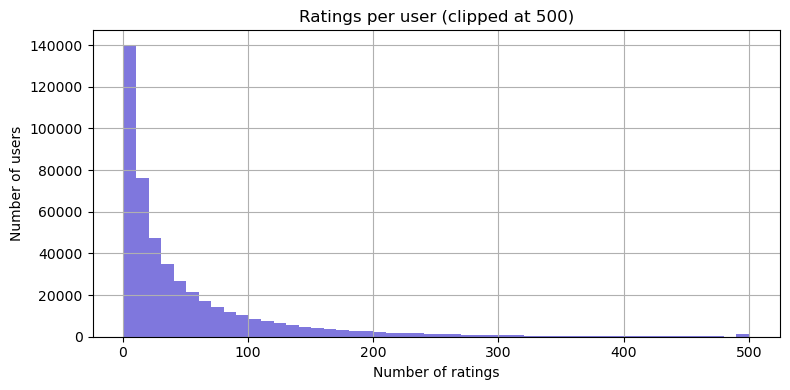

In [8]:
user_activity = df.groupby('user_id')['rating'].count()

print("Avg ratings per user:", user_activity.mean().round(1))
print("Max ratings by one user:", user_activity.max())
print("Min ratings by one user:", user_activity.min())

plt.figure(figsize=(8,4))
user_activity.clip(upper=500).hist(bins=50, color='#7F77DD')
plt.title('Ratings per user (clipped at 500)')
plt.xlabel('Number of ratings')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

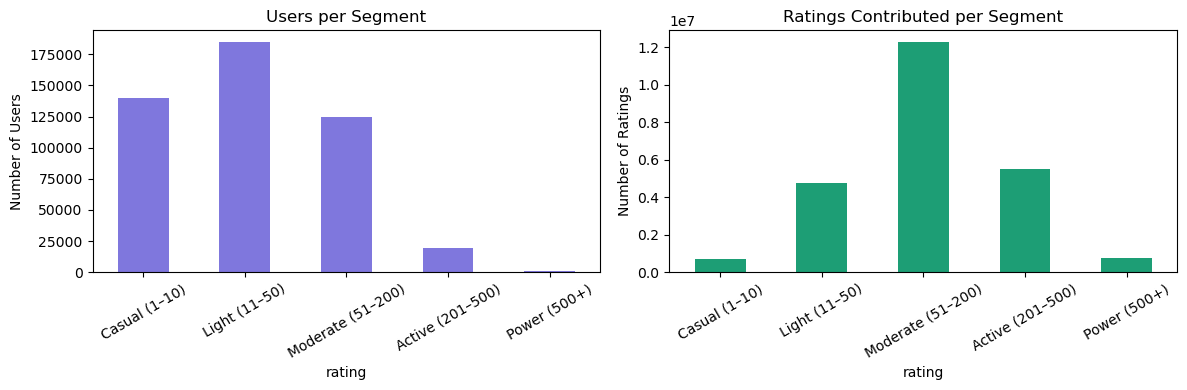

Casual (1–10): 140,127 users, 710,234 ratings (3.0% of total)
Light (11–50): 184,967 users, 4,776,461 ratings (19.9% of total)
Moderate (51–200): 124,836 users, 12,300,101 ratings (51.1% of total)
Active (201–500): 19,734 users, 5,510,799 ratings (22.9% of total)
Power (500+): 1,094 users, 756,169 ratings (3.1% of total)


In [17]:
bins = [0, 10, 50, 200, 500, float('inf')]
labels = ['Casual (1–10)', 'Light (11–50)', 'Moderate (51–200)', 'Active (201–500)', 'Power (500+)']
user_activity = df.groupby('user_id')['rating'].count()
segments = pd.cut(user_activity, bins=bins, labels=labels)
seg_counts = segments.value_counts().sort_index()

# What % of total ratings come from each segment?
seg_ratings = user_activity.groupby(segments, observed=False).sum()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
seg_counts.plot(kind='bar', ax=ax1, color='#7F77DD', title='Users per Segment')
ax1.set_ylabel('Number of Users')
ax1.tick_params(axis='x', rotation=30)

seg_ratings.plot(kind='bar', ax=ax2, color='#1D9E75', title='Ratings Contributed per Segment')
ax2.set_ylabel('Number of Ratings')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

for seg in labels:
    u = seg_counts[seg]
    r = seg_ratings[seg]
    print(f"{seg}: {u:,} users, {r:,} ratings ({r/len(df):.1%} of total)")

In [18]:
user_stats = df.groupby('user_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).fillna(0)

# Bin by activity level and compare avg rating
user_stats['segment'] = pd.cut(user_stats['num_ratings'], bins=bins, labels=labels)
print(user_stats.groupby('segment', observed=False)[['avg_rating', 'rating_std']].mean().round(3))

                   avg_rating  rating_std
segment                                  
Casual (1–10)           3.705       0.839
Light (11–50)           3.702       0.999
Moderate (51–200)       3.649       0.969
Active (201–500)        3.493       0.963
Power (500+)            3.233       0.983


In [11]:
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)

total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Users: 470,758
Movies: 4,499
Ratings: 24,053,764
Sparsity: 98.8643%


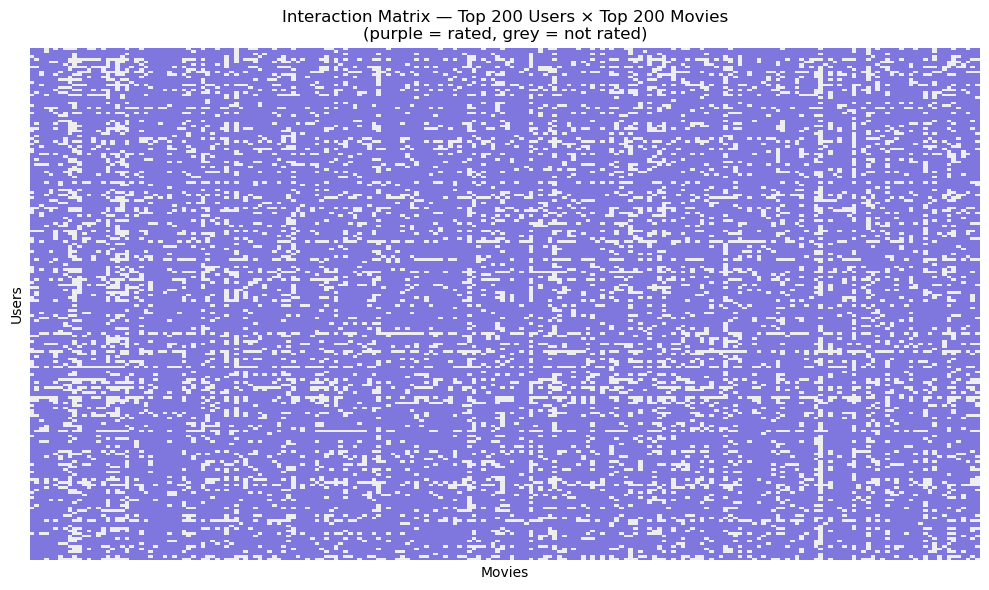

In [12]:
# Sample top 200 users and top 200 movies for visualization
top_users = df['user_id'].value_counts().head(200).index
top_movies = df['movie_id'].value_counts().head(200).index
sample = df[df['user_id'].isin(top_users) & df['movie_id'].isin(top_movies)]
pivot = sample.pivot_table(index='user_id', columns='movie_id', values='rating')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot.notna(), cbar=False, xticklabels=False, yticklabels=False,
            cmap=['#EEEEEE', '#7F77DD'])
plt.title('Interaction Matrix — Top 200 Users × Top 200 Movies\n(purple = rated, grey = not rated)')
plt.xlabel('Movies')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

In [13]:
movie_rc = df.groupby('movie_id')['rating'].count()
user_rc  = df.groupby('user_id')['rating'].count()

print("=== Cold Start Problem ===")
print(f"Movies with < 5 ratings : {(movie_rc < 5).sum():,}  ({(movie_rc < 5).mean():.1%} of all movies)")
print(f"Movies with < 10 ratings: {(movie_rc < 10).sum():,} ({(movie_rc < 10).mean():.1%} of all movies)")
print(f"Users  with < 5 ratings : {(user_rc < 5).sum():,}  ({(user_rc < 5).mean():.1%} of all users)")
print(f"Users  with < 10 ratings: {(user_rc < 10).sum():,} ({(user_rc < 10).mean():.1%} of all users)")

=== Cold Start Problem ===
Movies with < 5 ratings : 0  (0.0% of all movies)
Movies with < 10 ratings: 0 (0.0% of all movies)
Users  with < 5 ratings : 65,218  (13.9% of all users)
Users  with < 10 ratings: 129,803 (27.6% of all users)


      num_ratings  avg_rating
year                         
1999          426        3.11
2000       193255        3.31
2001       370691        3.34
2002       959548        3.35
2003      2397989        3.40
2004      7569628        3.59
2005     12562227        3.67


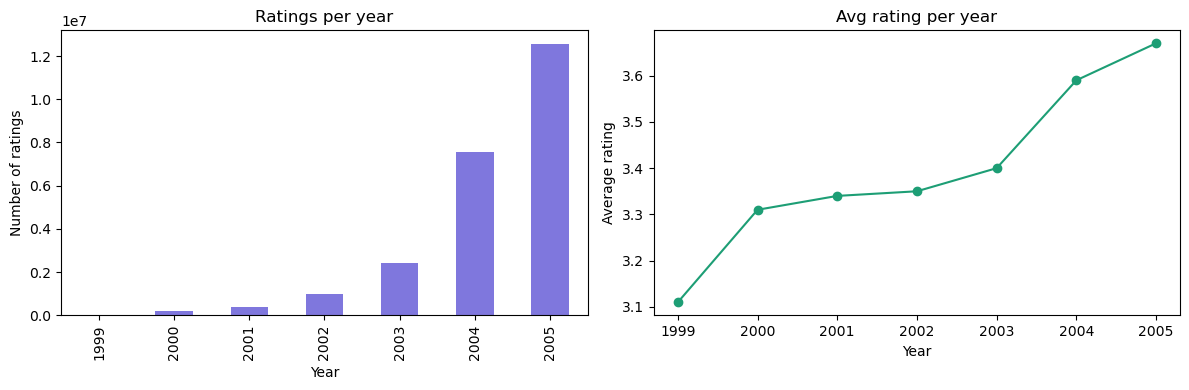

In [14]:
df['year'] = df['date'].dt.year

yearly = df.groupby('year').agg(
    num_ratings=('rating','count'),
    avg_rating=('rating','mean')
).round(2)

print(yearly)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

yearly['num_ratings'].plot(kind='bar', ax=ax1,
    color='#7F77DD', title='Ratings per year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of ratings')

yearly['avg_rating'].plot(ax=ax2, marker='o',
    color='#1D9E75', title='Avg rating per year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average rating')

plt.tight_layout()
plt.show()

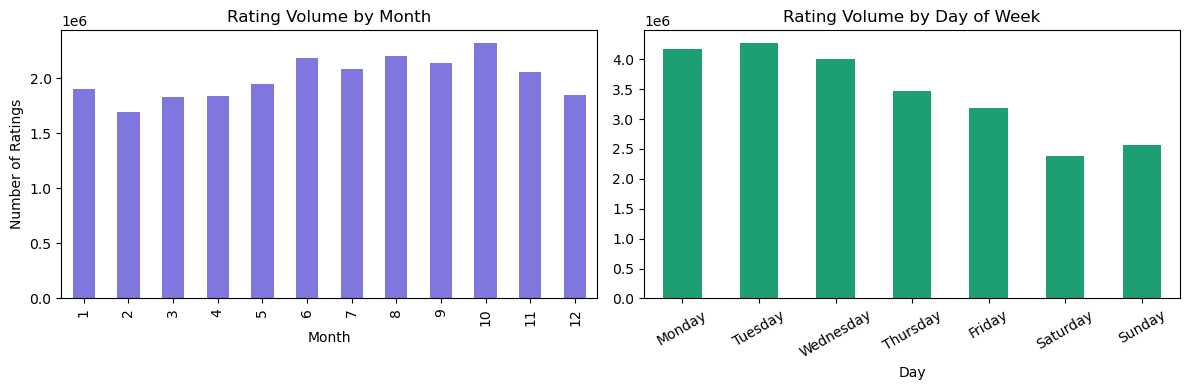

In [15]:
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('month')['rating'].count().plot(kind='bar', ax=ax1, color='#7F77DD',
                                            title='Rating Volume by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Ratings')

df.groupby('dayofweek')['rating'].count().reindex(day_order).plot(
    kind='bar', ax=ax2, color='#1D9E75', title='Rating Volume by Day of Week')
ax2.set_xlabel('Day')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

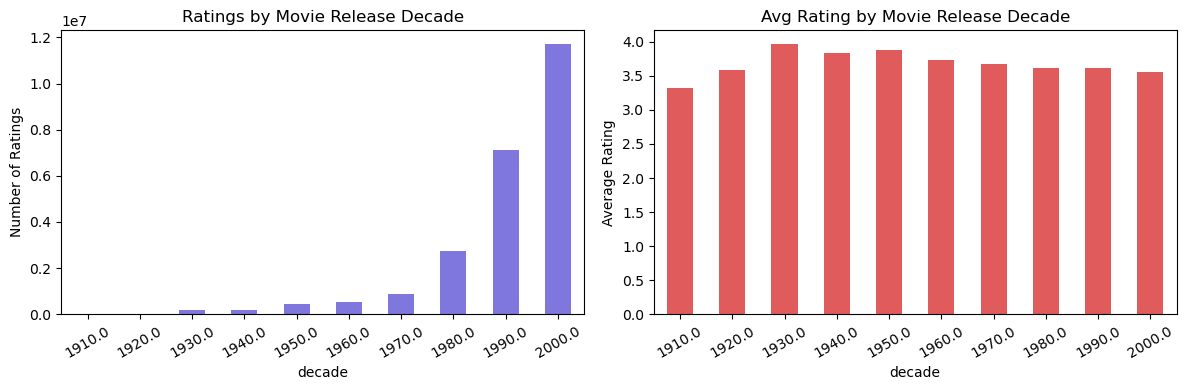

In [23]:
df_titles = df.merge(titles, on='movie_id')

df_titles = df_titles[df_titles['release_year'].notna() & (df_titles['release_year'] != 'NULL')]
df_titles['release_year'] = pd.to_numeric(df_titles['release_year'], errors='coerce')
df_titles['decade'] = (df_titles['release_year'] // 10) * 10

decade_stats = df_titles.groupby('decade').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
decade_stats['num_ratings'].plot(kind='bar', ax=ax1, color='#7F77DD',
                                  title='Ratings by Movie Release Decade')
ax1.set_ylabel('Number of Ratings')
ax1.tick_params(axis='x', rotation=30)

decade_stats['avg_rating'].plot(kind='bar', ax=ax2, color='#E05C5C',
                                 title='Avg Rating by Movie Release Decade')
ax2.set_ylabel('Average Rating')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# EDA Summary
> **Note:** Analysis based on `combined_data_1.txt` only (1 of 4 files). Full dataset has ~100M ratings across more decades.
## Key Findings
- Dataset has 470,758 users, 4,499 movies, 24,053,764 ratings (combined_data_1.txt subset)
- Sparsity is 98.86% — most user-movie pairs have no rating
- Average rating is 3.6 — users tend to rate positively; 88.9% of users have avg rating > 3
- Top rated movie by volume is Pirates of the Caribbean: The Curse of the Black Pearl (2003)
- Most active user rated 4,467 movies; the majority of users are casual (< 50 ratings)
- Power users (500+ ratings) rate harsher on average (3.23) vs casual users (3.71)
- Rating volume peaked in 2005; rating quality improved steadily from 3.11 (1999) to 3.67 (2005)
- Top 11.8% of movies (530) account for 80% of all ratings — strong long-tail effect
- 13.9% of users have fewer than 5 ratings — cold start is a prevalent problem

## Business Implications
- High sparsity means collaborative filtering must handle missing data well
- Popularity bias: a small fraction of movies dominate ratings — naive CF will over-recommend popular titles
- Power users are harsher raters — weighting all users equally may distort recommendations
- Cold start affects a large portion of users and movies — needs explicit handling in the model
- Rising avg ratings over time may reflect mainstream user growth or increased selectivity
- Long-tail content (low-rating-count movies) will be systematically under-recommended without special handling